In [0]:
sales_data = [
(1001,"Laptop","Electronics","Hyderabad",2,65000,"Completed"),
(1002,"Mobile","Electronics","Bangalore",3,25000,"Completed"),
(1003,"Chair","Furniture","Mumbai",5,3500,"Pending"),
(1004,"Table","Furniture","Delhi",2,12000,"Completed"),
(1005,"Shoes","Fashion","Chennai",4,2500,"Completed"),
(1006,"Watch","Fashion","Pune",1,8000,"Cancelled"),
(1007,"TV","Electronics","Hyderabad",1,45000,"Completed"),
(1008,"Laptop","Electronics","Mumbai",2,65000,"Completed"),
(1009,"Chair","Furniture","Delhi",3,3500,"Pending"),
(1010,"Shoes","Fashion","Bangalore",5,2500,"Completed"),
(1011,"Mobile","Electronics","Chennai",4,25000,"Completed"),
(1012,"Watch","Fashion","Hyderabad",2,8000,"Completed"),
(1013,"TV","Electronics","Delhi",1,45000,"Completed"),
(1014,"Table","Furniture","Pune",3,12000,"Cancelled"),
(1015,"Laptop","Electronics","Bangalore",1,65000,"Completed"),
(1016,"Mobile","Electronics","Mumbai",2,25000,"Completed"),
(1017,"Shoes","Fashion","Delhi",4,2500,"Pending"),
(1018,"Chair","Furniture","Hyderabad",2,3500,"Completed"),
(1019,"TV","Electronics","Chennai",1,45000,"Completed"),
(1020,"Watch","Fashion","Bangalore",3,8000,"Completed")
]
columns = [
"order_id",
"product",
"category",
"city",
"quantity",
"price",
"status"
]
df = spark.createDataFrame(
 sales_data,
 columns
)
display(df)

order_id,product,category,city,quantity,price,status
1001,Laptop,Electronics,Hyderabad,2,65000,Completed
1002,Mobile,Electronics,Bangalore,3,25000,Completed
1003,Chair,Furniture,Mumbai,5,3500,Pending
1004,Table,Furniture,Delhi,2,12000,Completed
1005,Shoes,Fashion,Chennai,4,2500,Completed
1006,Watch,Fashion,Pune,1,8000,Cancelled
1007,TV,Electronics,Hyderabad,1,45000,Completed
1008,Laptop,Electronics,Mumbai,2,65000,Completed
1009,Chair,Furniture,Delhi,3,3500,Pending
1010,Shoes,Fashion,Bangalore,5,2500,Completed


In [0]:
display(df.select("category").distinct())

from pyspark.sql.functions import col

df = df.withColumn(
    "revenue",
    col("quantity") * col("price")
)

display(df)

category
Electronics
Furniture
Fashion


order_id,product,category,city,quantity,price,status,revenue
1001,Laptop,Electronics,Hyderabad,2,65000,Completed,130000
1002,Mobile,Electronics,Bangalore,3,25000,Completed,75000
1003,Chair,Furniture,Mumbai,5,3500,Pending,17500
1004,Table,Furniture,Delhi,2,12000,Completed,24000
1005,Shoes,Fashion,Chennai,4,2500,Completed,10000
1006,Watch,Fashion,Pune,1,8000,Cancelled,8000
1007,TV,Electronics,Hyderabad,1,45000,Completed,45000
1008,Laptop,Electronics,Mumbai,2,65000,Completed,130000
1009,Chair,Furniture,Delhi,3,3500,Pending,10500
1010,Shoes,Fashion,Bangalore,5,2500,Completed,12500


In [0]:
city_revenue_df = df.groupBy("city").sum("revenue")

display(city_revenue_df)

city,sum(revenue)
Hyderabad,198000
Bangalore,176500
Mumbai,197500
Delhi,89500
Chennai,155000
Pune,44000


Databricks visualization. Run in Databricks to view.

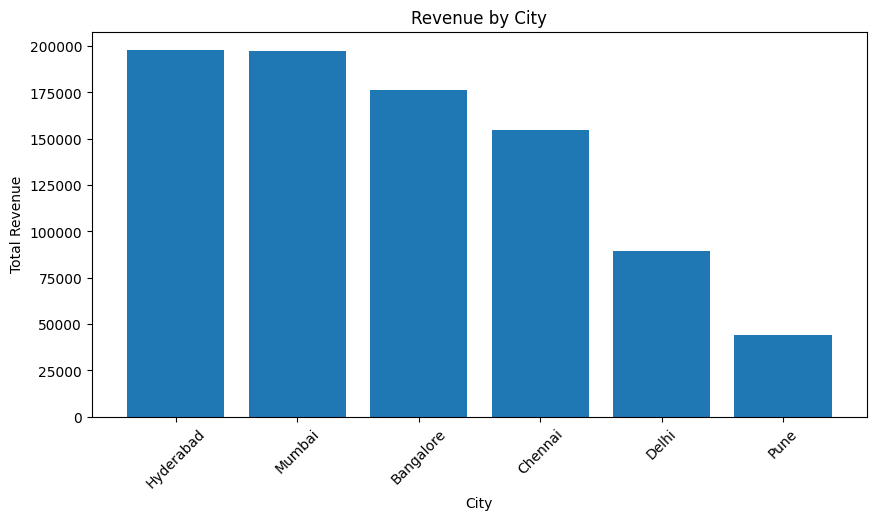

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum

city_revenue_df = df.groupBy("city").agg(
    sum("revenue").alias("total_revenue")
).orderBy(col("total_revenue").desc())

city_pd = city_revenue_df.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

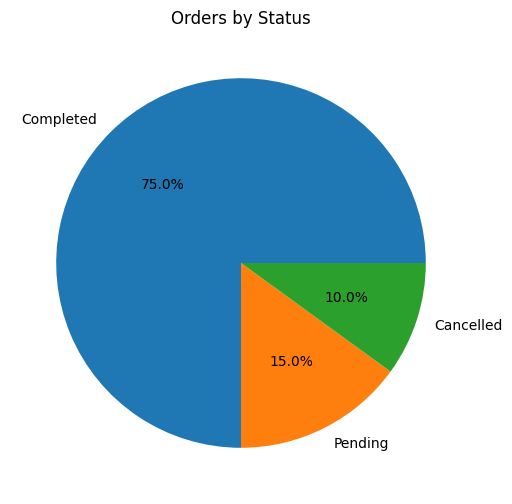

In [0]:
status_df = df.groupBy("status").count()

status_pd = status_df.toPandas()

plt.figure(figsize=(6, 6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Orders by Status")
plt.show()

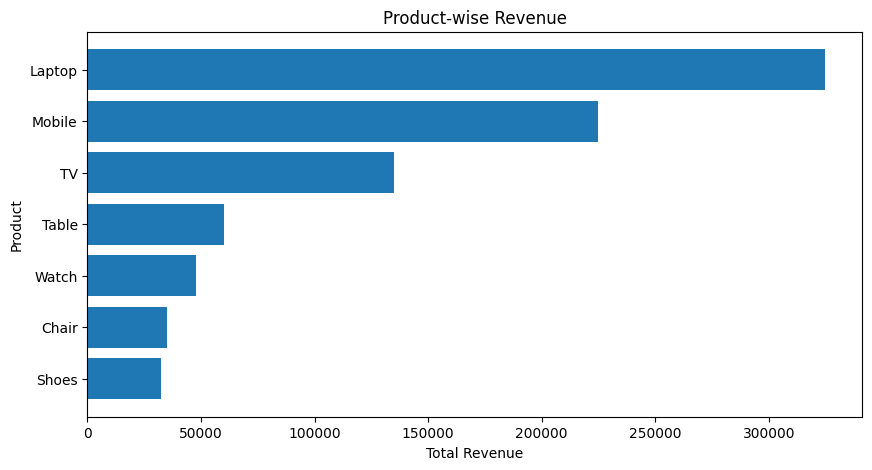

In [0]:
product_revenue_df = df.groupBy("product").agg(
    sum("revenue").alias("total_revenue")
).orderBy(col("total_revenue").desc())

product_pd = product_revenue_df.toPandas()

plt.figure(figsize=(10, 5))
plt.barh(product_pd["product"], product_pd["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Product-wise Revenue")
plt.gca().invert_yaxis()
plt.show()

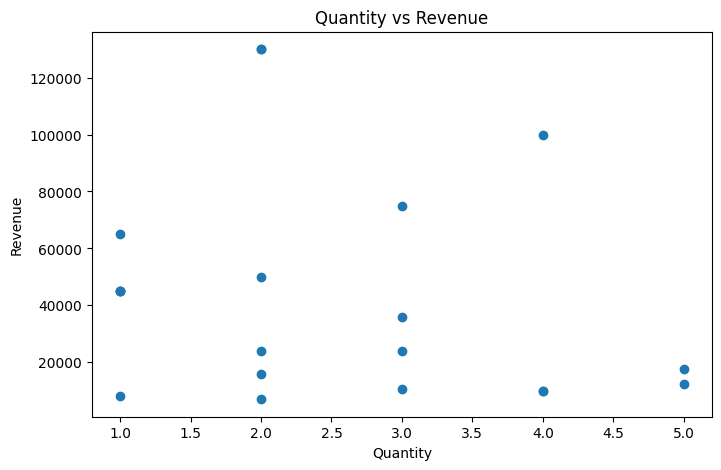

In [0]:
scatter_pd = df.select(
    "quantity",
    "revenue",
    "product"
).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(scatter_pd["quantity"], scatter_pd["revenue"])
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.show()

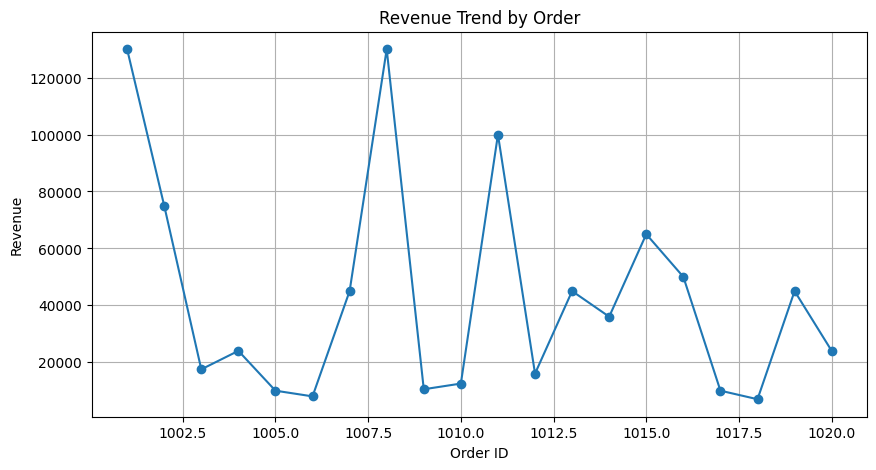

In [0]:
order_pd = df.select(
    "order_id",
    "revenue"
).orderBy("order_id").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(order_pd["order_id"], order_pd["revenue"], marker="o")
plt.xlabel("Order ID")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Order")
plt.grid(True)
plt.show()